##So before jumping directly into the actual pipeline, we must have an idea about what were are doing
###The Encoder-Decoder Architecture
####1. So Encoder is basically a neural netowrk model where we feed input x, it is then converted into the hidden representations, then the decoder side of neural netowrk takes those hidden representations and produces x̄
####2. The goal of the architecture is to minimise the loss = ||x-x̄||^2
Sobasically the the architecture must produce the original output from the given hidden representations

###The Undercomplete Autoencoder
####1. Now an undercomplete auto encoder is something where the features of the input data are reduce ==> hidden representations has less but the most significant features because remember when they go into decoder they have to produce the output closest to input and hence the quality of those hidden representation have to very good

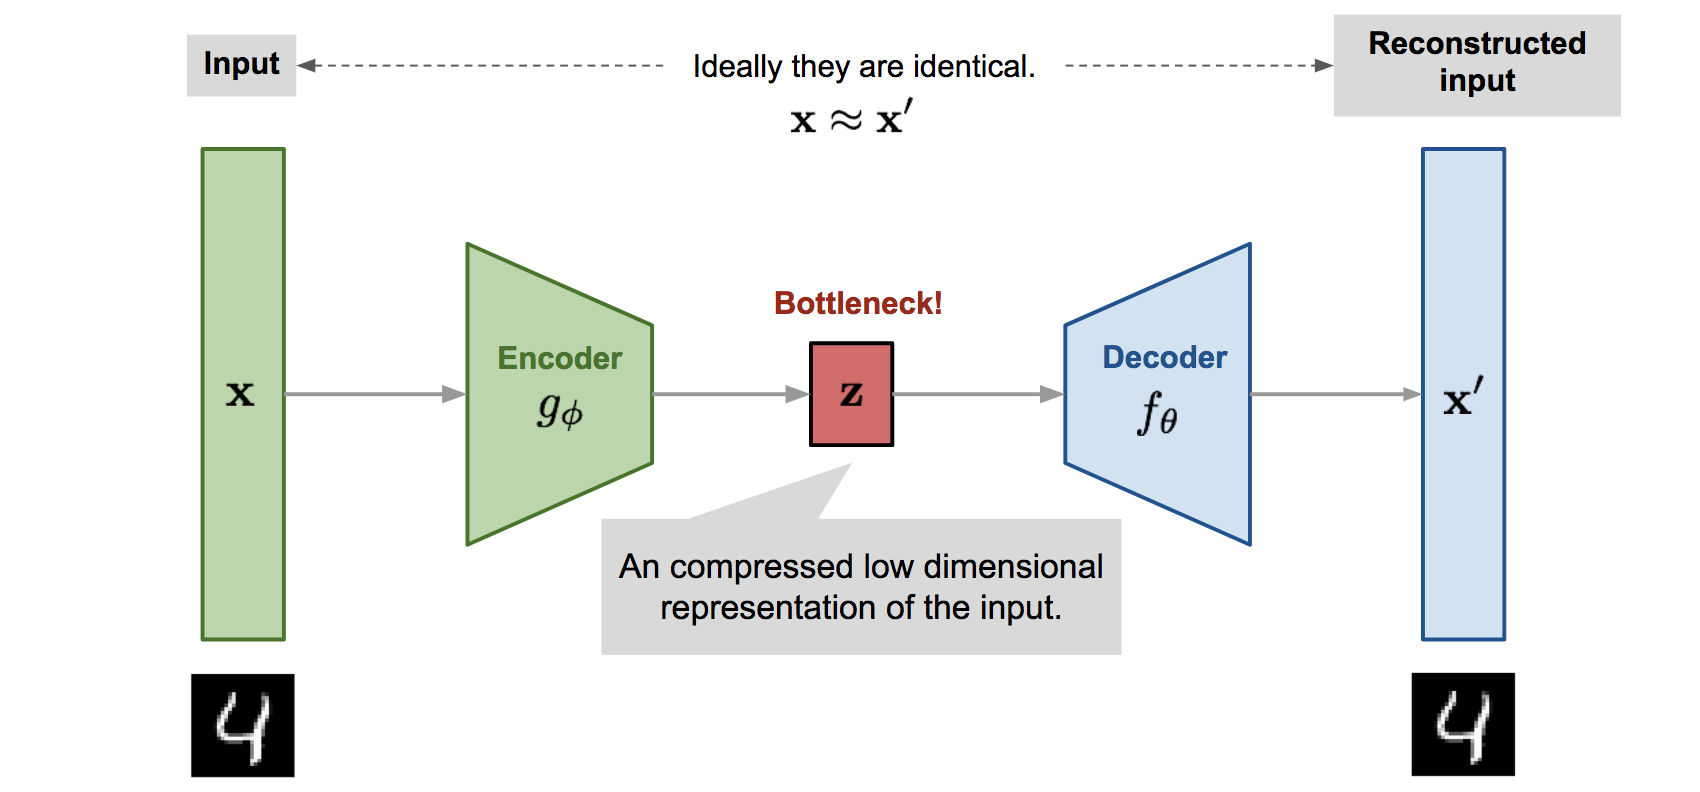

###So how does this help i financial fraud detection??

The idea is quite straightforward:

1. Due to the bottleneck architecture of the neural network, it is forced to learn a condensed representation from which to reproduce the original input.
2. We feed it only normal transactions, which it will learn to reproduce with high fidelity.
3. As a consequence, if a fraud transaction is sufficiently distinct from normal transactions, the auto-encoder will have trouble reproducing it with its learned weights, and the subsequent reconstruction loss will be high.
4. Anything above a specific loss (treshold) will be flagged as anomalous and thus labeled as fraud.


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "creditcard.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#renaming the class coloumn to prevent any syntax/matching variable errors
df.columns = map(str.lower, df.columns)
df.rename(columns={'class': 'label'}, inplace=True)

df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,label
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
import numpy as np
# add a negligible amount to avoid taking the log of 0
df['log10_amount'] = np.log10(df.amount + 0.00001)

In [ ]:
#just making the df a bit more nonfrauder
df = df[
    [col for col in df if col not in ['label', 'log10_amount']] +
    ['log10_amount', 'label']
]

In [ ]:
df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v22,v23,v24,v25,v26,v27,v28,amount,log10_amount,label
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,2.174990,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.429754,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,2.578249,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,2.091667,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,1.845036,0


##Train - Validate and Test Split
###Ao as out plan of action, we'll keep only good non fraud transactions in our training set, and combine every other entry with the fraud data in the test split
###However Validation will contain only non fraud for generalization and prevent overfitting as well (if heavy overfitting happens it might happen that apart form fraud detection it might detect the non fraud examples not present in the training as fraud as well)

##Outline


## 1. Training (Only Non-Fraud Data)

- ### 1.1 Split into:
  - **i.** Training the autoencoder
  - **ii.** Validating the network's ability to generalize

---

## 2. Testing (Mix of Fraud and Non-Fraud Data)

- Treated as unseen/new data  
- Attempt to **locate outliers**
- Compute **reconstruction loss**
- Apply a **threshold** to flag potential fraud

In [ ]:
df = df.drop(['time', 'amount'], axis=1)

# splitting by class
fraud = df[df.label == 1]
nonfraud = df[df.label == 0]


In [ ]:
print(f"""Shape of the datasets:
    nonfraud (rows, cols) = {nonfraud.shape}
    fraud (rows, cols) = {fraud.shape}""")

Shape of the datasets:
    nonfraud (rows, cols) = (284315, 30)
    fraud (rows, cols) = (492, 30)


In [ ]:
#some parameters
TRAINING_SAMPLE = 220000
VALIDATE_SIZE = 0.1


In [ ]:
import pandas as pd
# shuffling our nonfraud dataset
nonfraud = nonfraud.sample(frac=1).reset_index(drop=True)

# training set: exlusively non-fraud transactions
x_train = nonfraud.iloc[:TRAINING_SAMPLE].drop('label', axis=1)

# testing  set: the remaining non-fraud + all the fraud
x_test = nonfraud.iloc[TRAINING_SAMPLE:]
x_test = pd.concat([x_test, fraud])

In [ ]:
from sklearn.model_selection import train_test_split

# train // validate - no labels since they're all clean anyway
x_train, x_validate = train_test_split(x_train, test_size=VALIDATE_SIZE)
# manually splitting the labels from the test df
x_test, y_test = x_test.drop('label', axis=1).values, x_test.label.values

In [ ]:
print(f"""Shape of the datasets:
    training (rows, cols) = {x_train.shape}
    validate (rows, cols) = {x_validate.shape}
    test  (rows, cols) = {x_test.shape}""")

Shape of the datasets:
    training (rows, cols) = (198000, 29)
    validate (rows, cols) = (22000, 29)
    test  (rows, cols) = (64807, 29)


In [ ]:
#ONe thing to note and to understand is that making sure your data is normally distributed can help stochastic gradient descent converge more effectively

####But at what point and what should be the method to normalize
A good answer is this
Don't forget that testing data points represent real-world data. Feature normalization (or data standardization) of the explanatory (or predictor) variables is a technique used to center and normalise the data by subtracting the mean and dividing by the variance. If you take the mean and variance of the whole dataset you'll be introducing future information into the training explanatory variables (i.e. the mean and variance).

Therefore, you should perform feature normalisation over the training data. Then perform normalisation on testing instances as well, but this time using the mean and variance of training explanatory variables. In this way, we can test and evaluate whether our model can generalize well to new, unseen data points

In [ ]:
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline

# configure our pipeline
pipeline = Pipeline([('normalizer', Normalizer()),('scaler', MinMaxScaler())])

In [ ]:
pipeline.fit(x_train) #this code does nothing but to apply sequentially whatever is defined above in Pipeline

Pipeline(steps=[('normalizer', Normalizer()), ('scaler', MinMaxScaler())])

In [ ]:
#as said in the answer whatever transformation you get from training apply it to validate and test set for better generalization and production of unseen data
x_train_transformed = pipeline.transform(x_train)
x_validate_transformed = pipeline.transform(x_validate)

##Getting to training of Auto Encoder

In [ ]:
import tensorflow as tf

# data dimensions // hyperparameters
input_dim = x_train_transformed.shape[1]
BATCH_SIZE = 256
EPOCHS = 100

autoencoder = tf.keras.models.Sequential([

    # encoder model
    tf.keras.layers.Dense(input_dim, activation='elu', input_shape=(input_dim, )),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(2, activation='elu'),

    # decoder
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(input_dim, activation='elu')

])


autoencoder.compile(optimizer="adam", loss="mse", metrics=["acc"])

autoencoder.summary();

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 29)             │           870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 29)             │           493 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,221 (8.68 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

Each layer:

Takes input from the previous layer's output

Applies a linear transformation using weights and biases

Applies the activation function ('elu')

And produces output of shape (batch_size, units) where units is the number we pass (like 16, 8, etc.)

In [ ]:
from datetime import datetime

yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='autoencoder_best_weights.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)



# callbacks argument only takes a list
cb = [early_stop, save_model]

In [ ]:
history = autoencoder.fit(
    x_train_transformed, x_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_validate_transformed, x_validate_transformed)
);

Epoch 1/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.1788 - loss: 0.0665 - val_acc: 0.2602 - val_loss: 0.0164
Epoch 2/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.2598 - loss: 0.0162 - val_acc: 0.3277 - val_loss: 0.0147
Epoch 3/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.3345 - loss: 0.0145 - val_acc: 0.3435 - val_loss: 0.0142
Epoch 4/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.3448 - loss: 0.0141 - val_acc: 0.3539 - val_loss: 0.0138
Epoch 5/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.3559 - loss: 0.0137 - val_acc: 0.3612 - val_loss: 0.0136
Epoch 6/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.3659 - loss: 0.0135 - val_acc: 0.3639 - val_loss: 0.0131
Epoch 7/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.3678 - loss: 0.0129 - val_acc: 0.3614 - val_loss: 0.0128
Epoch 8/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.3706 - loss: 0.0127 - val_acc: 0.3729 - val_loss: 0.0126
Epoch 9/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/

In [ ]:
x_test_transformed = pipeline.transform(x_test) #transforming the x-test with training dataset ke tranformation parametrs scaling wagerah

In [ ]:
reconstructions = autoencoder.predict(x_test_transformed)

2026/2026 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:
#now we have the reconstructions xbar with us and also x orignal data, so let's find out the reconstruction loss and filter out the transactions based on that

In [ ]:
# calculating the mean squared error reconstruction loss per row in the numpy array
mse = np.mean(np.power(x_test_transformed - reconstructions, 2), axis=1)

In [ ]:
print(mse[100:])

[0.00596434 0.005171   0.00594874 ... 0.0290481  0.02557808 0.00344586]


In [ ]:
y_test

array([0, 0, 0, ..., 1, 1, 1])

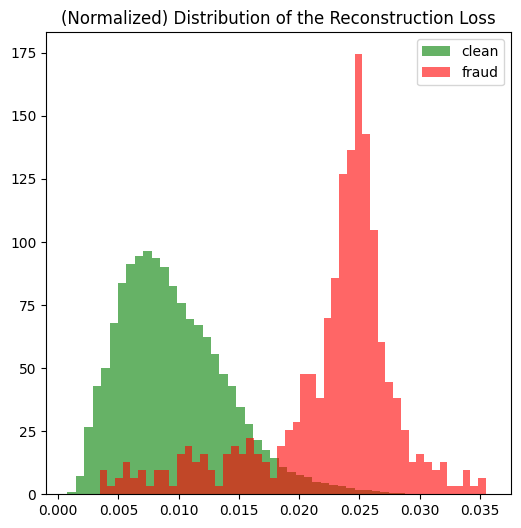

In [ ]:
import matplotlib.pyplot as plt
#mse is calculated from x_test and y_test also has the same origin and hence the below code
#When you pass a boolean array as an index in NumPy, it filters the array by position, keeping only the values where the corresponding boolean is True.
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=50, density=True, label="clean", alpha=.6, color="green")
ax.hist(fraud, bins=50, density=True, label="fraud", alpha=.6, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

Although some transactions seem to fool the autoencoder, the fraudulent transactions clearly have a distinguishing element in their data that sets them apart from clean ones.

In [ ]:
THRESHOLD = 3

def mad_score(points):
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)

    return 0.6745 * ad / mad

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD

In [ ]:
print(f"Detected {np.sum(outliers):,} outliers in a total of {np.size(z_scores):,} transactions [{np.sum(outliers)/np.size(z_scores):.2%}].")

Detected 1,185 outliers in a total of 64,807 transactions [1.83%].


In [ ]:
#Well, if you remember this 84807 sample contained around 492 fraud cases --> obviusly the detected 876 includes both fraud and non fraud (that lie in the fraud territory)
#but still out of such imbalanced dataset, auto encoders can be a good tool to get the fraud entries

In [ ]:
from sklearn.metrics import (confusion_matrix,
                             precision_recall_curve)

# get (mis)classification
cm = confusion_matrix(y_test, outliers)

# true/false positives/negatives
(tn, fp, fn, tp) = cm.flatten()

In [ ]:
print(f"""The classifications using the MAD method with threshold={THRESHOLD} are as follows:
{cm}

% of transactions labeled as fraud that were correct (precision): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% of fraudulent transactions were caught succesfully (recall):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}""")

The classifications using the MAD method with threshold=3 are as follows:
[[63475   840]
 [  147   345]]

% of transactions labeled as fraud that were correct (precision): 345/(840+345) = 29.11%
% of fraudulent transactions were caught succesfully (recall):    345/(147+345) = 70.12%


In [ ]:
tn = 63475
tp = 345
fn = 147
fp = 840
accuracy = (tp+tn)/(tp+tn+fp+fn)

In [ ]:
accuracy

0.9847701637168824

In [ ]:
#here 1 = fraud and 0 = non fraud

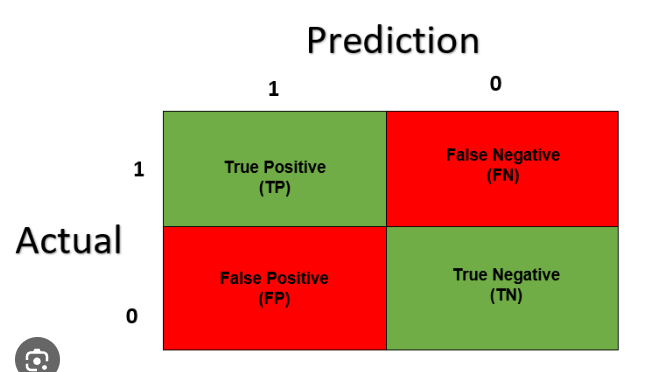

In [ ]:
#above is a classification matrix. however note that the matrix given by cm is slightly different organised
#[[TN  FP]
# [FN  TP]]